# Data Manipulation with Pandas & Visualization with Matplotlib & Seaborn

**Date:** 05/11/2025

In [12]:
#pip install pandas numpy matplotlib seaborn scikit-learn

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

* Melb Data: https://www.kaggle.com/code/dansbecker/handling-missing-values/data?select=melb_data.csv
* Pandas Documentation: https://pandas.pydata.org/docs/
* Pandas Cheat Sheet: https://pandas.pydata.org/Pandas_Cheat_Sheet.pdf

In [2]:
DATA_PATH = os.path.join(
    "/Users/cesar/sandbox/ai_programming_foundations/data",
    "melb_data.csv"
)

In [3]:
df = pd.read_csv(DATA_PATH)

Nota: Los objetos de Pandas se llaman **DataFrames**

In [4]:
df #.tail(5)

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000,S,Biggin,03/12/16,2.5,3067,...,1,1.0,202,NaN,NaN,Yarra,-37.79960,144.99840,Northern Metropolitan,4019
1,Abbotsford,25 Bloomburg St,2,h,1035000,S,Biggin,04/02/16,2.5,3067,...,1,0.0,156,79.0,1900.0,Yarra,-37.80790,144.99340,Northern Metropolitan,4019
2,Abbotsford,5 Charles St,3,h,1465000,SP,Biggin,04/03/17,2.5,3067,...,2,0.0,134,150.0,1900.0,Yarra,-37.80930,144.99440,Northern Metropolitan,4019
3,Abbotsford,40 Federation La,3,h,850000,PI,Biggin,04/03/17,2.5,3067,...,2,1.0,94,NaN,NaN,Yarra,-37.79690,144.99690,Northern Metropolitan,4019
4,Abbotsford,55a Park St,4,h,1600000,VB,Nelson,04/06/16,2.5,3067,...,1,2.0,120,142.0,2014.0,Yarra,-37.80720,144.99410,Northern Metropolitan,4019
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13575,Wheelers Hill,12 Strada Cr,4,h,1245000,S,Barry,26/08/17,16.7,3150,...,2,2.0,652,NaN,1981.0,NaN,-37.90562,145.16761,South-Eastern Metropolitan,7392
13576,Williamstown,77 Merrett Dr,3,h,1031000,SP,Williams,26/08/17,6.8,3016,...,2,2.0,333,133.0,1995.0,NaN,-37.85927,144.87904,Western Metropolitan,6380
13577,Williamstown,83 Power St,3,h,1170000,S,Raine,26/08/17,6.8,3016,...,2,4.0,436,NaN,1997.0,NaN,-37.85274,144.88738,Western Metropolitan,6380
13578,Williamstown,96 Verdon St,4,h,2500000,PI,Sweeney,26/08/17,6.8,3016,...,1,5.0,866,157.0,1920.0,NaN,-37.85908,144.89299,Western Metropolitan,6380


In [ ]:
df.columns

Index(['Suburb', 'Address', 'Rooms', 'Type', 'Price', 'Method', 'SellerG',
       'Date', 'Distance', 'Postcode', 'Bedroom2', 'Bathroom', 'Car',
       'Landsize', 'BuildingArea', 'YearBuilt', 'CouncilArea', 'Lattitude',
       'Longtitude', 'Regionname', 'Propertycount'],
      dtype='object')

In [14]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

In [15]:
# Columnas del clima
features = [
    'Rooms', 
    'BuildingArea',
    'Landsize',
    'Distance',
    'Bathroom',
    ]

# columna objectivo a predecir
target = ['Price']

In [16]:
df[features+target].isna().sum()

Rooms              0
BuildingArea    6450
Landsize           0
Distance           0
Bathroom           0
Price              0
dtype: int64

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    df[features].fillna(0),
    df[target],
    test_size=0.2,
    random_state=210
)

In [19]:
# Modelo para 5 vecinos mas cercanos
model = KNeighborsRegressor(n_neighbors=5)

In [72]:
#model.__dict__

In [20]:
model.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [22]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

In [23]:
# error en conjunto de entrenamiento
error_train = mean_squared_error(y_train, y_train_pred)

# error en conjunto de prueba
error_test = mean_squared_error(y_test, y_test_pred)

In [24]:
print("Error RSME en train:", round(error_train,2) )

Error RSME en train: 164705819717.06


In [25]:
print("Error RSME en test:", round(error_test,2) )

Error RSME en test: 292857138013.22


In [91]:
y_train.values

array([[ 940000],
       [ 646250],
       [1110000],
       ...,
       [ 881000],
       [1310000],
       [1171000]], shape=(10864, 1))

In [95]:
eval_res = pd.DataFrame({
    "price": y_train.values.flatten(),
    "price_predicted": y_train_pred.flatten(),
})

In [ ]:
eval_res["abs_error"] = np.abs(
    eval_res["price"]- eval_res["price_predicted"]
    )

In [98]:
eval_res

,price,price_predicted,abs_error
0,940000,1906664.88,966664.88
1,646250,1125338.50,479088.50
2,1110000,980287.00,129713.00
3,585000,1155446.00,570446.00
4,480750,753027.50,272277.50
...,...,...,...
10859,1401000,1504505.38,103505.38
10860,705000,1183007.50,478007.50
10861,881000,1130065.00,249065.00
10862,1310000,1088977.50,221022.50


<Axes: xlabel='abs_error', ylabel='Count'>

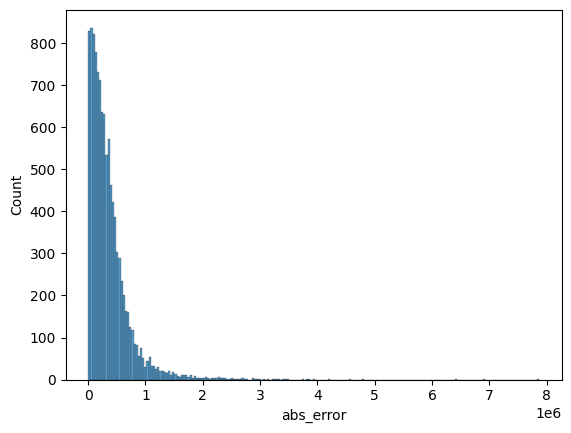

In [99]:
sns.histplot(
    eval_res,
    x="abs_error"
)

In [104]:
eval_res.query("abs_error < 2000").shape

(45, 3)

In [105]:
eval_res.query("abs_error  < 2000")

,price,price_predicted,abs_error
87,692000,691975.00,25.00
138,1110000,1108880.00,1120.00
181,850000,851251.90,1251.90
325,468000,468163.01,163.01
413,845000,845926.90,926.90
792,1275000,1275950.00,950.00
963,990000,989650.00,350.00
1088,597000,597555.00,555.00
1940,1100000,1100320.00,320.00
1980,435000,435298.00,298.00


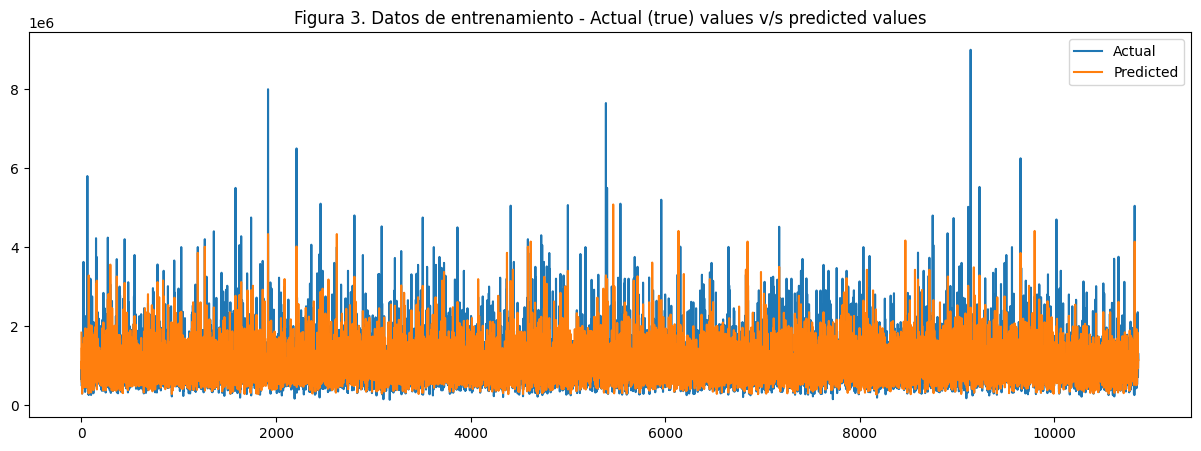

In [26]:
# Plotting graph of Actual (true) values and predicted values
plt.figure(figsize=(15,5))

plt.plot(y_train.reset_index(drop=True))
plt.plot(list(y_train_pred))
plt.title('Figura 3. Datos de entrenamiento - Actual (true) values v/s predicted values')
plt.legend(["Actual", "Predicted"])
plt.show()

In [43]:
neighbours = [2, 5, 10, 20, 50, 70, 100]

models_regresion = {
    i: KNeighborsRegressor(n_neighbors=i)
    for i in neighbours
    }


In [45]:
models_regresion

{2: KNeighborsRegressor(n_neighbors=2),
 5: KNeighborsRegressor(),
 10: KNeighborsRegressor(n_neighbors=10),
 20: KNeighborsRegressor(n_neighbors=20),
 50: KNeighborsRegressor(n_neighbors=50),
 70: KNeighborsRegressor(n_neighbors=70),
 100: KNeighborsRegressor(n_neighbors=100)}

In [55]:
errors_train = []
errors_test = []

for model_name in models_regresion.keys():

    print("Modelo:", model_name)
    model = models_regresion[model_name]

    # Ajusta el modelo con los datos de prueba
    model.fit(X_train,y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # error en conjunto de entrenamiento y prueba
    error_train = mean_squared_error(y_train, y_train_pred)
    error_test = mean_squared_error(y_test, y_test_pred)

    errors_train.append(error_train)
    errors_test.append(error_test)

    # errores
    print("Error RSME en train:", round(error_train,2) )
    print("Error RSME en test:", round(error_test,2) )

    print("----------------------------------------------")

    


Modelo: 2
Error RSME en train: 91041937060.33
Error RSME en test: 338241430400.71
----------------------------------------------
Modelo: 5
Error RSME en train: 164705819717.06
Error RSME en test: 292857138013.22
----------------------------------------------
Modelo: 10
Error RSME en train: 199050460154.9
Error RSME en test: 273946571133.42
----------------------------------------------
Modelo: 20
Error RSME en train: 228063147146.65
Error RSME en test: 273003608757.15
----------------------------------------------
Modelo: 50
Error RSME en train: 256854034802.5
Error RSME en test: 286773015733.49
----------------------------------------------
Modelo: 70
Error RSME en train: 267739307128.78
Error RSME en test: 293412963070.55
----------------------------------------------
Modelo: 100
Error RSME en train: 277627824604.53
Error RSME en test: 300313061887.06
----------------------------------------------


In [64]:
knn_errors_train = pd.DataFrame(
    {
        "k": neighbours,
        "type": "train",
        "rmse": errors_train,
    }
)

knn_errors_test = pd.DataFrame(
    {
        "k": neighbours,
        "type": "test",
        "rmse": errors_test,
    }
)

In [65]:
pd.concat([knn_errors_train, knn_errors_test])

,k,type,rmse
0,2,train,9.104194e+10
1,5,train,1.647058e+11
2,10,train,1.990505e+11
3,20,train,2.280631e+11
4,50,train,2.568540e+11
5,70,train,2.677393e+11
6,100,train,2.776278e+11
0,2,test,3.382414e+11
1,5,test,2.928571e+11
2,10,test,2.739466e+11


In [ ]:
knn_errors = pd.DataFrame(
    {
        "k": neighbours,
        "rmse_train": errors_train,
        "rmse_test": errors_test
    }
)

knn_errors

,k,rmse_train,rmse_test
0,2,9.104194e+10,3.382414e+11
1,5,1.647058e+11,2.928571e+11
2,10,1.990505e+11,2.739466e+11
3,20,2.280631e+11,2.730036e+11
4,50,2.568540e+11,2.867730e+11
5,70,2.677393e+11,2.934130e+11
6,100,2.776278e+11,3.003131e+11


<Axes: xlabel='k', ylabel='rmse'>

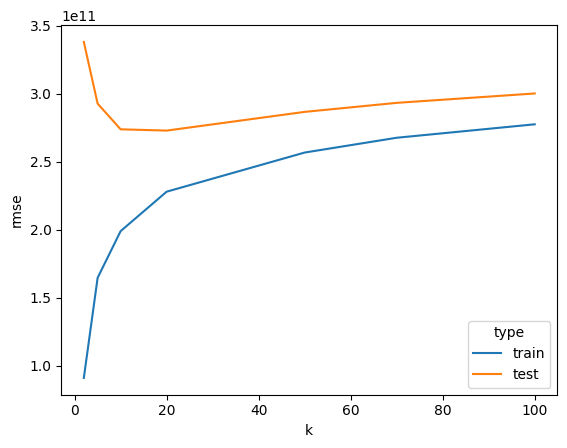

In [71]:
sns.lineplot(
    pd.concat([knn_errors_train, knn_errors_test]),
    x="k",
    y="rmse",
    hue="type",
    markers=True, dashes=True
)

<Axes: xlabel='k', ylabel='rmse_test'>

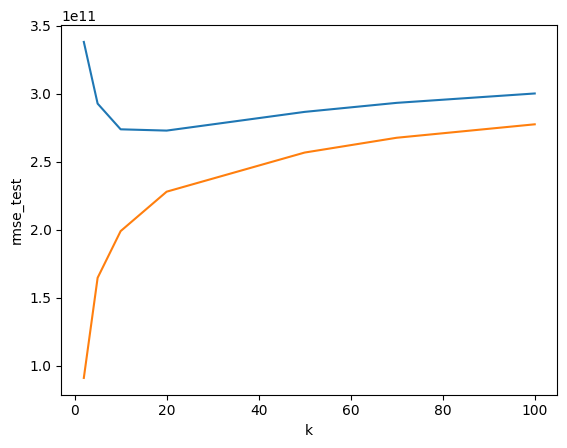

In [60]:
sns.lineplot(data=knn_errors, x="k", y="rmse_test")
sns.lineplot(data=knn_errors, x="k", y="rmse_train")

# Set the y-axis to a logarithmic scale
#ax.set_yscale('log')

In [38]:
error_train

277627824604.5314

In [27]:
from sklearn.linear_model import (
    LinearRegression,
    Lasso,
    Ridge,
    ElasticNet
)

# Instanciamos los diferentes modelos
lr = LinearRegression()
lr_lasso = Lasso(alpha=0.5)
lr_ridge = Ridge(alpha=0.5)
lr_elastict = ElasticNet(alpha=0.5, l1_ratio=0.3)

models_regresion = {
    'regression': lr,
    'lasso': lr_lasso,
    'ridge': lr_ridge,
    'elastic': lr_elastict
    }

In [28]:
for model_name in models_regresion.keys():

    print("Modelo:", model_name)
    model = models_regresion[model_name]

    # Ajusta el modelo con los datos de prueba
    model.fit(X_train,y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # error en conjunto de entrenamiento y prueba
    error_train = mean_squared_error(y_train, y_train_pred)
    error_test = mean_squared_error(y_test, y_test_pred)

    # errores
    print("Error RSME en train:", round(error_train,2) )
    print("Error RSME en test:", round(error_test,2) )

    print("----------------------------------------------")

    


Modelo: regression
Error RSME en train: 246149753299.97
Error RSME en test: 261981334224.06
----------------------------------------------
Modelo: lasso
Error RSME en train: 246149753300.56
Error RSME en test: 261981360751.23
----------------------------------------------
Modelo: ridge
Error RSME en train: 246149753581.69
Error RSME en test: 261981734978.89
----------------------------------------------
Modelo: elastic
Error RSME en train: 255222984980.16
Error RSME en test: 273185321279.25
----------------------------------------------


In [33]:
y_test.to_numpy()

array([[ 450000],
       [ 260000],
       [1640000],
       ...,
       [ 320000],
       [ 642000],
       [ 768000]], shape=(2716, 1))

In [31]:
y_test_pred

array([ 944953.74954078,  564096.88792044, 1357427.21389762, ...,
        659919.28341746,  984046.58909036,  617586.14985917],
      shape=(2716,))